In [1]:
import pandas as pd 
import miceforest as mf
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from plotnine import theme

In [2]:
data = pd.read_csv("Quality_of_Life_final.csv")

data.columns = data.columns.str.replace(' ', '_').str.replace(r'[^a-zA-Z0-9_]', '', regex=True)

data_for_imputation = data.drop(['Country', 'Year'], axis=1)

kernel = mf.ImputationKernel(
    data_for_imputation,
    num_datasets = 1,
    mean_match_candidates=0,
    random_state = 28
    )

kernel.mice(30)
imputed_data = kernel.complete_data(0)

imputed_data['Country'] = data['Country']
imputed_data['Year'] = data['Year']

imputed_data.to_csv("Testing.csv", index=False)

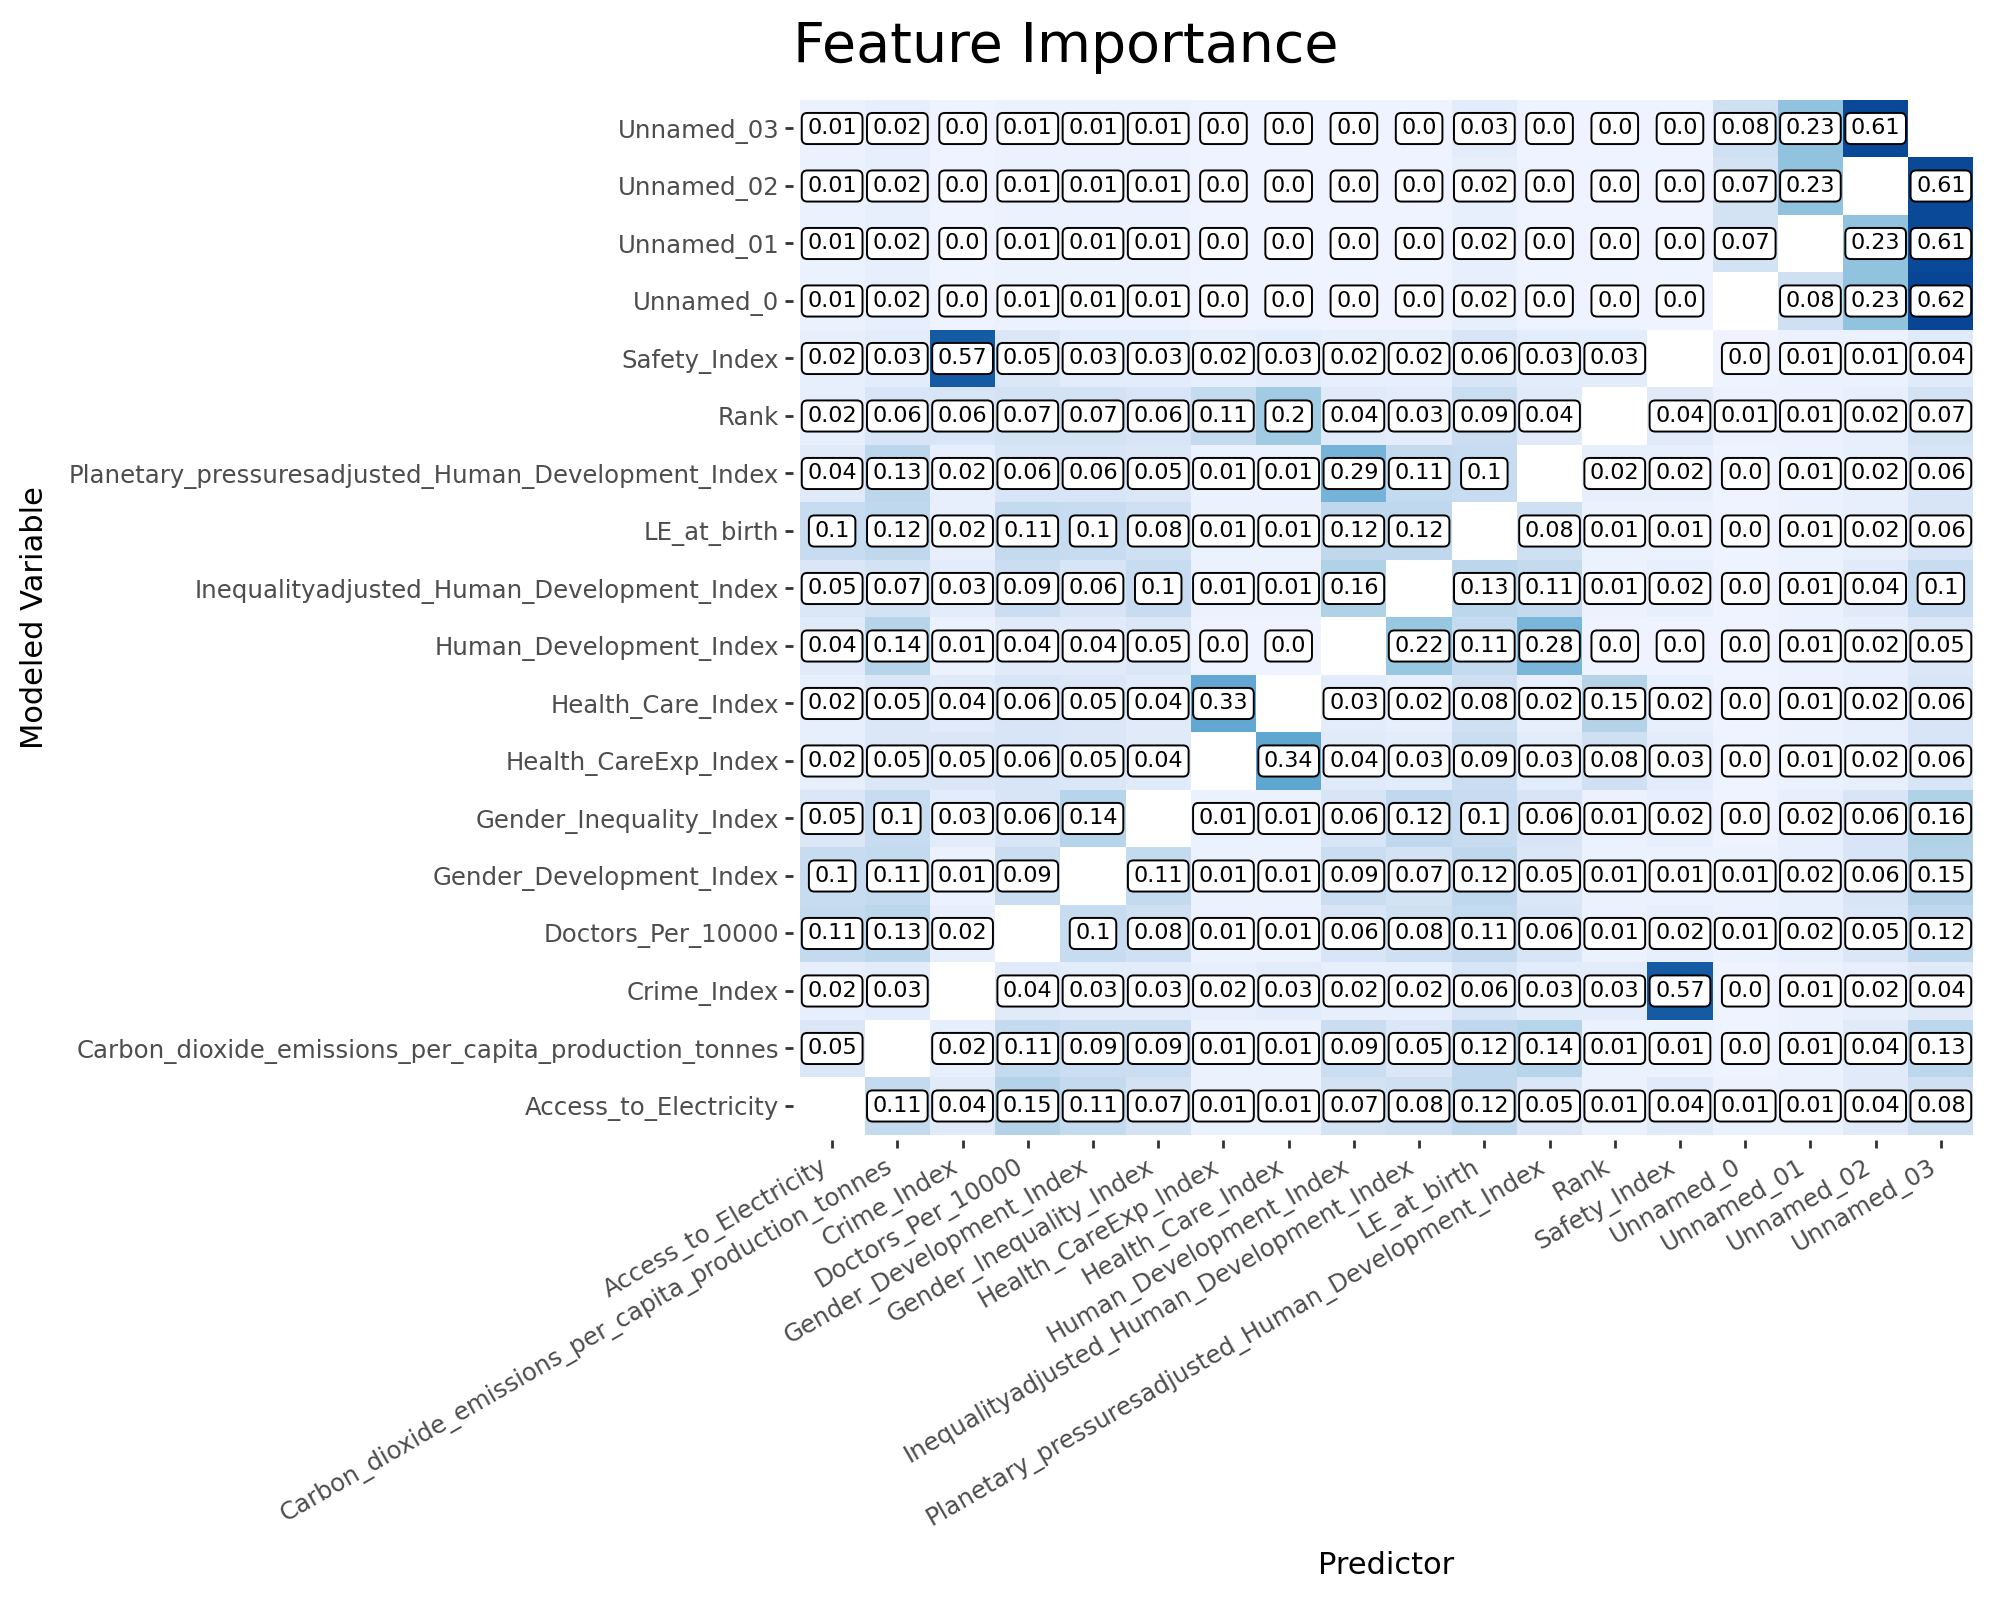

In [3]:
fig = kernel.plot_feature_importance(dataset=0)+theme(figure_size=(10, 8))
fig

In [4]:
fig=kernel.plot_imputed_distributions()
fig+=theme(figure_size=(10, 8))



In [9]:
fig
fig.save("imputed_distributions.png", dpi=300)

C:\Users\Admin\anaconda3\envs\Ease\Lib\site-packages\plotnine\ggplot.py:630: PlotnineWarning: Saving 10 x 8 in image.
C:\Users\Admin\anaconda3\envs\Ease\Lib\site-packages\plotnine\ggplot.py:631: PlotnineWarning: Filename: imputed_distributions.png


In [6]:
optimal_params = kernel.tune_parameters(
    dataset=0, 
    use_gbdt=True,
    num_iterations=500,
    random_state=1,
)
kernel.mice(1, variable_parameters=optimal_params)
pd.DataFrame(optimal_params)

,Health_CareExp_Index,Health_Care_Index,Rank,Safety_Index,Crime_Index,Inequalityadjusted_Human_Development_Index,Planetary_pressuresadjusted_Human_Development_Index,Doctors_Per_10000,Gender_Inequality_Index,Gender_Development_Index,Human_Development_Index,Carbon_dioxide_emissions_per_capita_production_tonnes,Unnamed_0,Unnamed_01,Unnamed_02,Unnamed_03,Access_to_Electricity,LE_at_birth
boosting,gbdt,gbdt,gbdt,gbdt,gbdt,gbdt,gbdt,gbdt,gbdt,gbdt,gbdt,gbdt,gbdt,gbdt,gbdt,gbdt,gbdt,gbdt
data_sample_strategy,bagging,bagging,bagging,bagging,bagging,bagging,bagging,bagging,bagging,bagging,bagging,bagging,bagging,bagging,bagging,bagging,bagging,bagging
num_iterations,499,500,209,499,500,500,500,500,500,500,500,500,500,500,500,500,500,500
max_depth,4,4,4,5,3,4,5,5,5,3,4,5,5,4,4,4,4,4
num_leaves,12,17,11,18,18,15,6,16,15,11,20,5,21,20,22,17,22,17
min_data_in_leaf,3,5,1,1,34,6,79,14,3,8,55,1,2,30,7,1,1,35
min_sum_hessian_in_leaf,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01
min_gain_to_split,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
bagging_fraction,0.580973,0.501521,0.582307,0.779917,0.484219,0.989755,0.572203,0.537392,0.809136,0.659727,0.759828,0.909158,0.686174,0.538817,0.835992,0.992306,0.569846,0.665478
feature_fraction_bynode,0.922566,0.299912,0.697415,0.778489,0.776686,0.621771,0.932327,0.643879,0.650828,0.487223,0.56711,0.743797,0.733165,0.857269,0.690684,0.80155,0.393391,0.361087


In [7]:
kernel.mice(30,variable_parameters=optimal_params)
imputed_data = kernel.complete_data(0)

imputed_data['Country'] = data['Country']
imputed_data['Year'] = data['Year']

imputed_data.to_csv('Healthcare_Imputation.csv', index=False)

C:\Users\Admin\AppData\Local\Temp\ipykernel_3544\602279902.py:12: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

C:\Users\Admin\AppData\Local\Temp\ipykernel_3544\602279902.py:14: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.



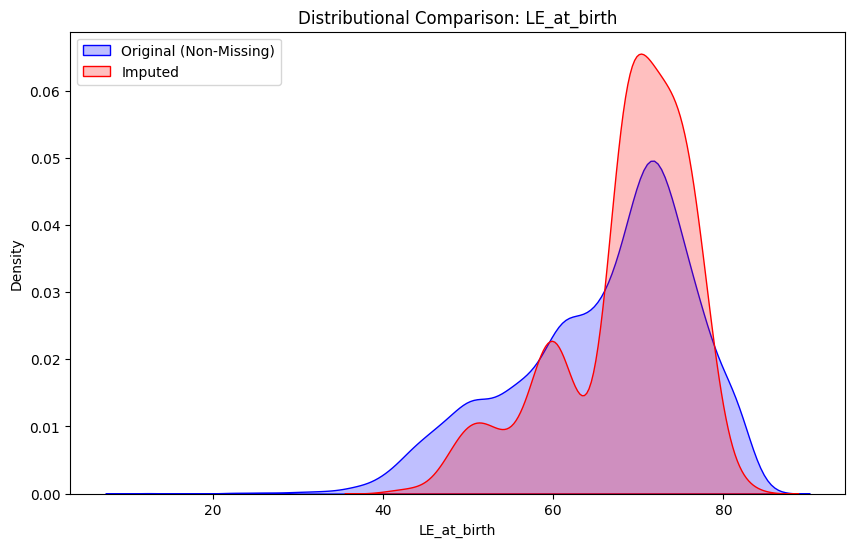

C:\Users\Admin\AppData\Local\Temp\ipykernel_3544\602279902.py:12: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

C:\Users\Admin\AppData\Local\Temp\ipykernel_3544\602279902.py:14: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.



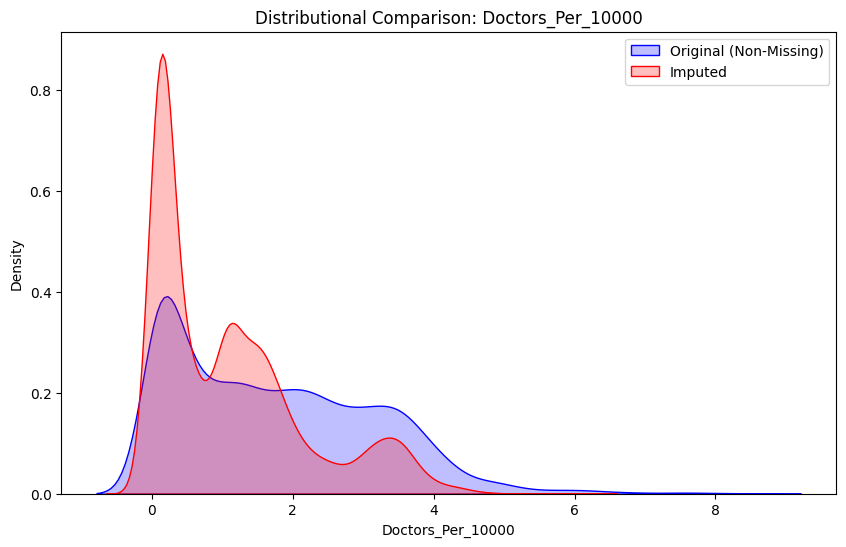

C:\Users\Admin\AppData\Local\Temp\ipykernel_3544\602279902.py:12: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

C:\Users\Admin\AppData\Local\Temp\ipykernel_3544\602279902.py:14: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.



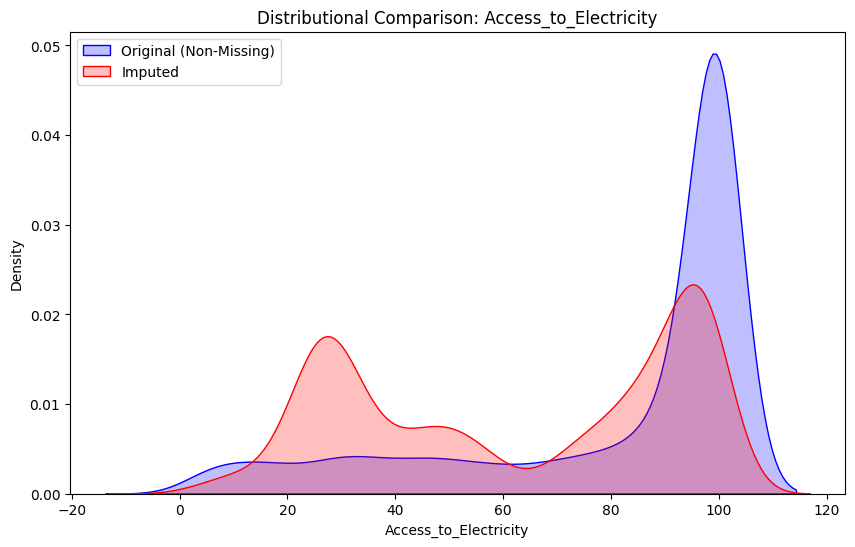

KeyError: 'Unnamed: 0.3'

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

original_data = pd.read_csv("Quality_of_Life_final.csv")

original_data_clean = original_data.drop(['Country', 'Year'], axis=1)
imputed_data_clean = imputed_data.drop(['Country', 'Year'], axis=1)

def plot_distributions(original, imputed, column_name):
    plt.figure(figsize=(10, 6))

    sns.kdeplot(original.dropna(), label="Original (Non-Missing)", color='blue', shade=True)
    missing_indices = original[original.isna()].index
    sns.kdeplot(imputed.loc[missing_indices], label="Imputed", color='red', shade=True)
    
    plt.title(f'Distributional Comparison: {column_name}')
    plt.legend()
    plt.show()


for column in original_data_clean.columns:
    plot_distributions(original_data_clean[column], imputed_data_clean[column], column)

In [ ]:
from sklearn.preprocessing import StandardScaler
import scipy.stats as stats
from factor_analyzer.factor_analyzer import calculate_kmo

df = pd.read_csv("Healthcare_imputation.csv")

df= df.interpolate(method='linear', limit_direction='forward', axis=0)

df_numeric = df.drop(columns=['Country', 'Year'])

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_numeric)

kmo_all,kmo_model=calculate_kmo(df_scaled)
kmo_model

For comparision metrics, we will use the mean value in place of the NaN values and then compare the two datasets, from the mean imputed data set we will delete some values at random and then use these models only to predict those values and then calculate the scores for comparision and then judge these models.